# Where a mixture fit starts: every supported initializer at one budget

Thirteen starts of the joint count-pair emission mixture (issues #887, #891),
each through the one seam, each polished by the same expectation-maximization
loop at the same budget, and read against the log-likelihood the generating
parameters reach on the same draw. No lattice and no chain: the emission model
alone, which is what a seeding of the coupled model's emission parameters sees.

Four terms the rest uses:

- A **`Budget`** (`opt.budget.Budget`) is a ceiling on the unit a method
  spends, held equal across methods so their results compare. Two are held
  here. The **initialization** may spend `Budget(Cost.SECONDS, 120)`: up to
  two minutes of wall clock seeding, the chain starts included, before the
  optimizer takes over; a start over it is refused. The **optimizer** spends
  `Budget(Cost.PASSES, 6)`: six passes, a pass being every pair scored under
  every component.
- A **nat** is the unit of a log-likelihood difference in natural logarithms:
  a gap of `Δ = 1` nat is a likelihood ratio of `e ≈ 2.718`.
- The **loop** every start hands over to is the expectation-maximization
  iterations of `opt.emission_mixture.expectation_maximization`, one E step
  and one M step per pass, from equal weights.
- The **seam** is `opt.emission_mixture.CountPairSeeding`, which places a
  component on an observed pair. It is where every start ends, not a start of
  its own.

The instance is `emission_mixture/stress`: ten components of the joint
count-pair family, a negative-binomial total and a beta-binomial count of
successes out of it, over 3,000 pairs. It has no exact evidence, so the
reference is the **generating parameters' own value** on the draw, stated as
such. The count-pair mixture has no `theta` and is not an `Objective`, so the
four starts of `opt.initialize` and the three of `sample.initialize` run on a
surrogate, the Gaussian mixture over both channels, and none of the seven
applies to the count-pair likelihood itself; the Gaussian-mixture EM start
runs on the first channel alone, which is the one channel
`opt.mixture.expectation_maximization` fits.

In [1]:
import inspect
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from snakes_and_ladders.cost import Cost
from snakes_and_ladders.opt.budget import Budget, compare
from snakes_and_ladders.opt.emission_mixture import CountPairSeeding
from snakes_and_ladders.opt.initialize import quantile_locations
from snakes_and_ladders.qa.starts_table import build_table
from snakes_and_ladders.qa.style import discrete_palette, notebook_style
from snakes_and_ladders.sample import hmc
from snakes_and_ladders.search import mixture_starts
from snakes_and_ladders.search.mixture_starts import (
    DETERMINISTIC,
    STARTS,
    StartRow,
    TimedStart,
    Trial,
    instance_from,
)
from snakes_and_ladders.sim.emission_mixture import simulate_emission_mixture
from snakes_and_ladders.sim.fixtures import fixture

np.set_printoptions(precision=3, suppress=True)

## The instance, and the reference the starts are read against

`fixture` reads the declared file; nothing here builds an instance. The draw
is the fixture's own, under its declared seed, and the seam places a component
at the declared dispersion and concentration pooled over the components: one
pair carries no shape, so every start begins its components at those two.

In [2]:
# The declared instance: tests/regression/fixtures/emission_mixture/stress.yaml,
# its seed, its weights and its ten joint count-pair components.
declared = fixture("emission_mixture", "stress").params
# One draw of 3,000 pairs under the declared seed, with the generating
# component of each retained beside it.
dataset = simulate_emission_mixture(declared)
# The seam: a component on an observed pair, at the pooled dispersion and
# concentration, in the joint form the fixture declares.
at = CountPairSeeding(
    float(declared.components.total.dispersion.mean()),
    float(declared.components.concentration.mean()),
    joint=True,
)
# The draw, its truth and the seam as the one object every start reads.
instance = instance_from(dataset, at)
# The mixture log-likelihood at the generating parameters: the reference.
REFERENCE = instance.reference
print(
    "components",
    instance.n_components,
    "pairs",
    instance.n_samples,
    "seam dispersion",
    at.dispersion,
    "concentration",
    at.concentration,
)
print(f"the generating parameters reach {REFERENCE:.1f} nats")

components 10 pairs 3000 seam dispersion 60.0 concentration 15.0
the generating parameters reach -28268.1 nats


## The starts

Each start's description is the first paragraph of its own docstring in
`search.mixture_starts`, so the text cannot drift from the code, and its
settings are read off the objects the module builds for it. The order is the
table's.

In [3]:
def first_paragraph(obj: object) -> str:
    # The first paragraph of an object's docstring, on one line.
    return " ".join((inspect.getdoc(obj) or "").split("\n\n")[0].split())


# A generator for the builders below. It seeds only the torch streams they
# make; no setting printed here reads it.
probe = np.random.default_rng(0)
chain = mixture_starts.chain_initializer(probe)
annealing = mixture_starts.annealing_initializer(probe)
ladder = mixture_starts.tempering_initializer(probe)
restarts = mixture_starts.restart_initializer(probe)
tilt = mixture_starts.perturbation()
# The quantile levels `quantile_locations` takes, read off the function by
# asking it for the quantiles of the unit interval.
levels = quantile_locations(
    torch.linspace(0.0, 1.0, 1001, dtype=torch.float64), instance.n_components
)
schedule = annealing.schedule
SETTINGS = {
    "prior": "totals log-uniform over the observed range, fractions uniform on (0, 1)",
    "data": f"{instance.n_components} pairs, without replacement",
    "kmeans++": "squared Euclidean distance over the raw pair",
    "emission++": "the Bregman divergence of the seam's own family",
    "gaussian-em": (
        f"{mixture_starts.GAUSSIAN_EM_ITERATIONS} iterations from one k-means++ "
        f"start, a path entry every {mixture_starts.PATH_STRIDE}"
    ),
    "objective": "the surrogate's nominated point",
    "perturbed": f"tilt {tilt.magnitude:g} in unconstrained coordinates, alternating sign",
    "restart": (
        f"{restarts.n_starts} points at spread {restarts.scale:g} in unconstrained "
        f"coordinates, the best by surrogate value kept"
    ),
    "quantile": "levels " + ", ".join(f"{q:.2f}" for q in levels.tolist()),
    "burn-in": (
        f"{mixture_starts.BURN_IN_ITERATIONS} EM iterations on "
        f"{mixture_starts.BURN_IN_FRACTION:.0%} of the pairs"
    ),
    "hmc": (
        f"step {chain.step_size:g}, {chain.n_steps} leapfrog steps a proposal, "
        f"{chain.burn_in} warm-up draws discarded, {chain.n_samples} kept"
    ),
    "anneal": (
        f"{type(schedule).__name__} from {schedule.start:g} to {schedule.end:g} "
        f"over {schedule.n_steps} proposals, step {annealing.step_size:g}, "
        f"{annealing.n_steps} leapfrog steps a proposal"
    ),
    "tempering": (
        f"ladder {ladder.temperatures}, {ladder.n_rounds} rounds of one transition "
        f"per rung, step {ladder.step_size:g}, {ladder.n_steps} leapfrog steps; "
        f"exchange: {first_paragraph(hmc.parallel_tempering)}"
    ),
}
ORDER = list(STARTS)
for name in ORDER:
    print(f"{name:11s} {first_paragraph(STARTS[name])}")
    print(f"{'':11s}   {SETTINGS[name]}")

prior       Components drawn from a prior over the observed range, reading no pair.
              totals log-uniform over the observed range, fractions uniform on (0, 1)
data        ``uniform_start``: components on pairs drawn uniformly without replacement.
              10 pairs, without replacement
kmeans++    ``kmeans_plus_plus`` on the raw pair, its centres handed to the seam.
              squared Euclidean distance over the raw pair
emission++  ``plus_plus_start``: D-squared sampling under the family's Bregman divergence.
              the Bregman divergence of the seam's own family
gaussian-em The Gaussian mixture fitted to the first channel from k-means++, its means the locations.
              500 iterations from one k-means++ start, a path entry every 25
objective   ``FromObjective``: the surrogate's own nominated point.
              the surrogate's nominated point
perturbed   ``Perturbed``: that point, tilted off a symmetry it may be stationary at.
              tilt 0.1 in

## Every start, once per seed

The trials run through `opt.budget.compare`, which hands each (start, seed)
cell to `snakes_and_ladders.parallel` on a pool of four worker processes, one
per core of the host, each at one intra-op thread, each cell seeding its own
generator `default_rng([seed, 0])`, so a cell draws the same stream at every
worker count. Each cell is a `search.mixture_starts.TimedStart`: the start
runs inside a `track` block nested in the one the polish runs in, so every
sample it records carries its own time, and the handover is one sample of its
own. The comparison's budget is the initialization's 120 s; the spend
reported against it is the seconds to the handover.

**One trial for now, and `TRIALS` is the one constant to raise.** A polished
fit here is about 3 s on one core, most of it the M step's per-component
solves (issue #892). The loop over seeds, the trials column and the
`[min, max]` range below already read `TRIALS`; a start that reads no
generator runs once whatever it is.

In [4]:
#: Seeds of every start that reads a generator: one for now, ten once issue
#: #892 lands. The one constant to raise.
TRIALS = [0]

#: Cells run at once, one worker process per core of the 4-core host.
WORKERS = 4

#: The two budgets: the initialization's ceiling and the optimizer's passes.
SEEDING = Budget(Cost.SECONDS, 120)
POLISH = Budget(Cost.PASSES, 6)

GROUPS = {
    "stochastic": ([n for n in ORDER if n not in DETERMINISTIC], TRIALS),
    "deterministic": ([n for n in ORDER if n in DETERMINISTIC], [0]),
}

load_before = os.getloadavg()
opened = time.perf_counter()
comparisons = {}
trials: dict[str, list[Trial]] = {}
for group, (names, seeds) in GROUPS.items():
    # Every (start, seed) cell of the group on the pool: its reached value,
    # its seconds to the handover, and the Trial it carries back.
    comparison = compare(
        {name: TimedStart(name, POLISH) for name in names},
        [instance],
        SEEDING,
        seeds,
        workers=WORKERS,
        known=[-REFERENCE],
    )
    comparisons[group] = comparison
    # The outcomes are in start, instance, seed order: one block of seeds each.
    for row, name in enumerate(comparison.methods):
        block = comparison.outcomes[row * len(seeds) : (row + 1) * len(seeds)]
        trials[name] = [outcome.detail for outcome in block]
elapsed = time.perf_counter() - opened
load_after = os.getloadavg()

# One row per start, read against the reference, in the table's order.
rows = [StartRow.from_trials(name, trials[name], REFERENCE) for name in ORDER]
print(
    f"{sum(row.trials for row in rows)} fits of {len(rows)} starts, "
    f"{POLISH.size} {POLISH.unit} each, on {WORKERS} workers"
)

13 fits of 13 starts, 6 passes each, on 4 workers


## What each start reached

A row states, over its trials: the log-likelihood at the handover (seeded
value) and at the optimizer's budget (reached value), the **gap**, the
reference less the reached value, in nats, the passes the start itself
charged, and the bytes of the fitted state. A negative gap is a fit that
passed the generating parameters' value. At more than one trial the gap also
carries its range, `[min, max]`. Every number here is continuous in the seeds;
the recovery, the largest mean error and the seconds are in the next section.

In [5]:
COMPARED = (
    "start",
    "trials",
    "seeded value",
    "reached value",
    "gap (nats)",
    "passes",
    "state bytes",
)
HOST = ("start", "recovery", "mean relative error", "seconds", "seeding seconds")


def spread(values: tuple[float, ...], digits: int) -> str:
    # The mean, and the range beside it at more than one trial.
    mean = f"{np.mean(values):.{digits}f}"
    if len(values) == 1:
        return mean
    return f"{mean} [{min(values):.{digits}f}, {max(values):.{digits}f}]"


def cells(row: StartRow) -> dict[str, str]:
    # One row's columns, each a string.
    return {
        "start": row.start,
        "trials": "deterministic"
        if row.deterministic
        else f"{row.trials} trial{'s' if row.trials > 1 else ''}",
        "seeded value": f"{np.mean(row.seeded):.1f}",
        "reached value": f"{np.mean(row.reached):.1f}",
        "gap (nats)": spread(row.gap, 1),
        "passes": f"{row.passes:.1f}",
        "state bytes": str(row.state_bytes),
        "recovery": spread(row.recovery, 3),
        "mean relative error": spread(row.mean_error, 3),
        "seconds": spread(row.seconds, 2),
        "seeding seconds": spread(row.seeding_seconds, 2),
    }


def table(columns: tuple[str, ...]) -> str:
    # A markdown table of every row, in the order of ORDER.
    lines = ["| " + " | ".join(columns) + " |", "|" + "---|" * len(columns)]
    lines += ["| " + " | ".join(cells(row)[c] for c in columns) + " |" for row in rows]
    return "\n".join(lines)


print(f"gaps are nats below the {REFERENCE:.1f} the generating parameters reach")
print()
print(table(COMPARED))

gaps are nats below the -28268.1 the generating parameters reach

| start | trials | seeded value | reached value | gap (nats) | passes | state bytes |
|---|---|---|---|---|---|---|
| prior | 1 trial | -34360.9 | -28321.1 | 53.0 | 0.0 | 400 |
| data | 1 trial | -37846.2 | -28517.1 | 249.0 | 0.0 | 400 |
| kmeans++ | 1 trial | -31888.4 | -28356.8 | 88.7 | 1.0 | 400 |
| emission++ | 1 trial | -30416.8 | -28371.1 | 103.0 | 1.0 | 400 |
| gaussian-em | 1 trial | -29686.8 | -28340.5 | 72.4 | 500.0 | 400 |
| objective | deterministic | -30065.0 | -28468.7 | 200.6 | 0.0 | 400 |
| perturbed | deterministic | -30065.0 | -28468.7 | 200.6 | 0.0 | 400 |
| restart | 1 trial | -30065.0 | -28468.7 | 200.6 | 4.0 | 400 |
| quantile | deterministic | -30065.0 | -28468.7 | 200.6 | 0.0 | 400 |
| burn-in | 1 trial | -29148.0 | -28467.6 | 199.6 | 0.6 | 400 |
| hmc | 1 trial | -30096.8 | -28470.1 | 202.1 | 144.0 | 400 |
| anneal | 1 trial | -30061.7 | -28471.1 | 203.0 | 144.0 | 400 |
| tempering | 1 trial | -3

## What each start recovered, and what it cost in seconds

The **recovery** is the fraction of pairs the fit assigns to their generating
component, up to the best renaming of the components; the **mean relative
error** is the largest relative error left in a component's first-channel
mean over that renaming. Both are read through a permutation match whose
near-ties flip when a reduction is ordered differently, so they are not
reproducible text across hosts, and the **seconds** are a wall clock. The cell
is tagged `host-dependent`: the notebook checker runs it and does not compare
its text (`docs/nb/README.md`). Beneath the table are `opt.budget.compare`'s
own tables, hits of the reference and the whole seconds to the handover
against the 120 s ceiling, and the LaTeX table of gap and seconds per start
that `qa.starts_table` builds, printed and not written: `docs/tex/generated/`
holds the ledgers `infra/ledgers.sh` writes and is not committed, and no
document cites this table yet.

In [6]:
print(
    f"host: {os.cpu_count()} cores, {WORKERS} workers; 1-minute load "
    f"{load_before[0]:.2f} before the trials and {load_after[0]:.2f} after; "
    f"the trials took {elapsed:.0f} s"
)
print()
print(table(HOST))
for group, comparison in comparisons.items():
    print()
    print(f"{group} starts, {len(GROUPS[group][1])} seed(s):")
    print(comparison.table())
print()
# The LaTeX tabular of gap and seconds per start, and its caption.
body, caption = build_table(
    rows, instance="the emission-mixture stress fixture", passes=POLISH.size
)
print(body)
print()
print(caption)

host: 4 cores, 4 workers; 1-minute load 2.90 before the trials and 4.69 after; the trials took 29 s

| start | recovery | mean relative error | seconds | seeding seconds |
|---|---|---|---|---|
| prior | 0.626 | 0.632 | 7.38 | 0.00 |
| data | 0.292 | 0.691 | 7.40 | 0.00 |
| kmeans++ | 0.344 | 3.399 | 6.79 | 0.01 |
| emission++ | 0.392 | 1.301 | 7.27 | 0.29 |
| gaussian-em | 0.495 | 0.870 | 5.41 | 1.06 |
| objective | 0.509 | 0.204 | 2.90 | 0.00 |
| perturbed | 0.509 | 0.204 | 2.74 | 0.00 |
| restart | 0.509 | 0.204 | 4.10 | 0.00 |
| quantile | 0.509 | 0.204 | 2.68 | 0.00 |
| burn-in | 0.335 | 0.581 | 5.22 | 1.25 |
| hmc | 0.483 | 0.206 | 4.32 | 0.66 |
| anneal | 0.417 | 0.230 | 3.01 | 0.24 |
| tempering | 0.537 | 0.181 | 2.86 | 0.22 |

stochastic starts, 1 seed(s):
| method | hits of 1 | mean gap | seconds spent |
| --- | --- | --- | --- |
| prior | 0/1 | 53 | 1 of 120 |
| data | 0/1 | 249 | 1 of 120 |
| kmeans++ | 0/1 | 88.7 | 1 of 120 |
| emission++ | 0/1 | 103 | 1 of 120 |
| gaussia

## Where each start places its components, and where the fit leaves them

Two panels per start, seed 0: the components as seeded (left) and as fitted at
the budget (right), each at its two channels' means, over the pairs in grey and
the generating components as crosses.

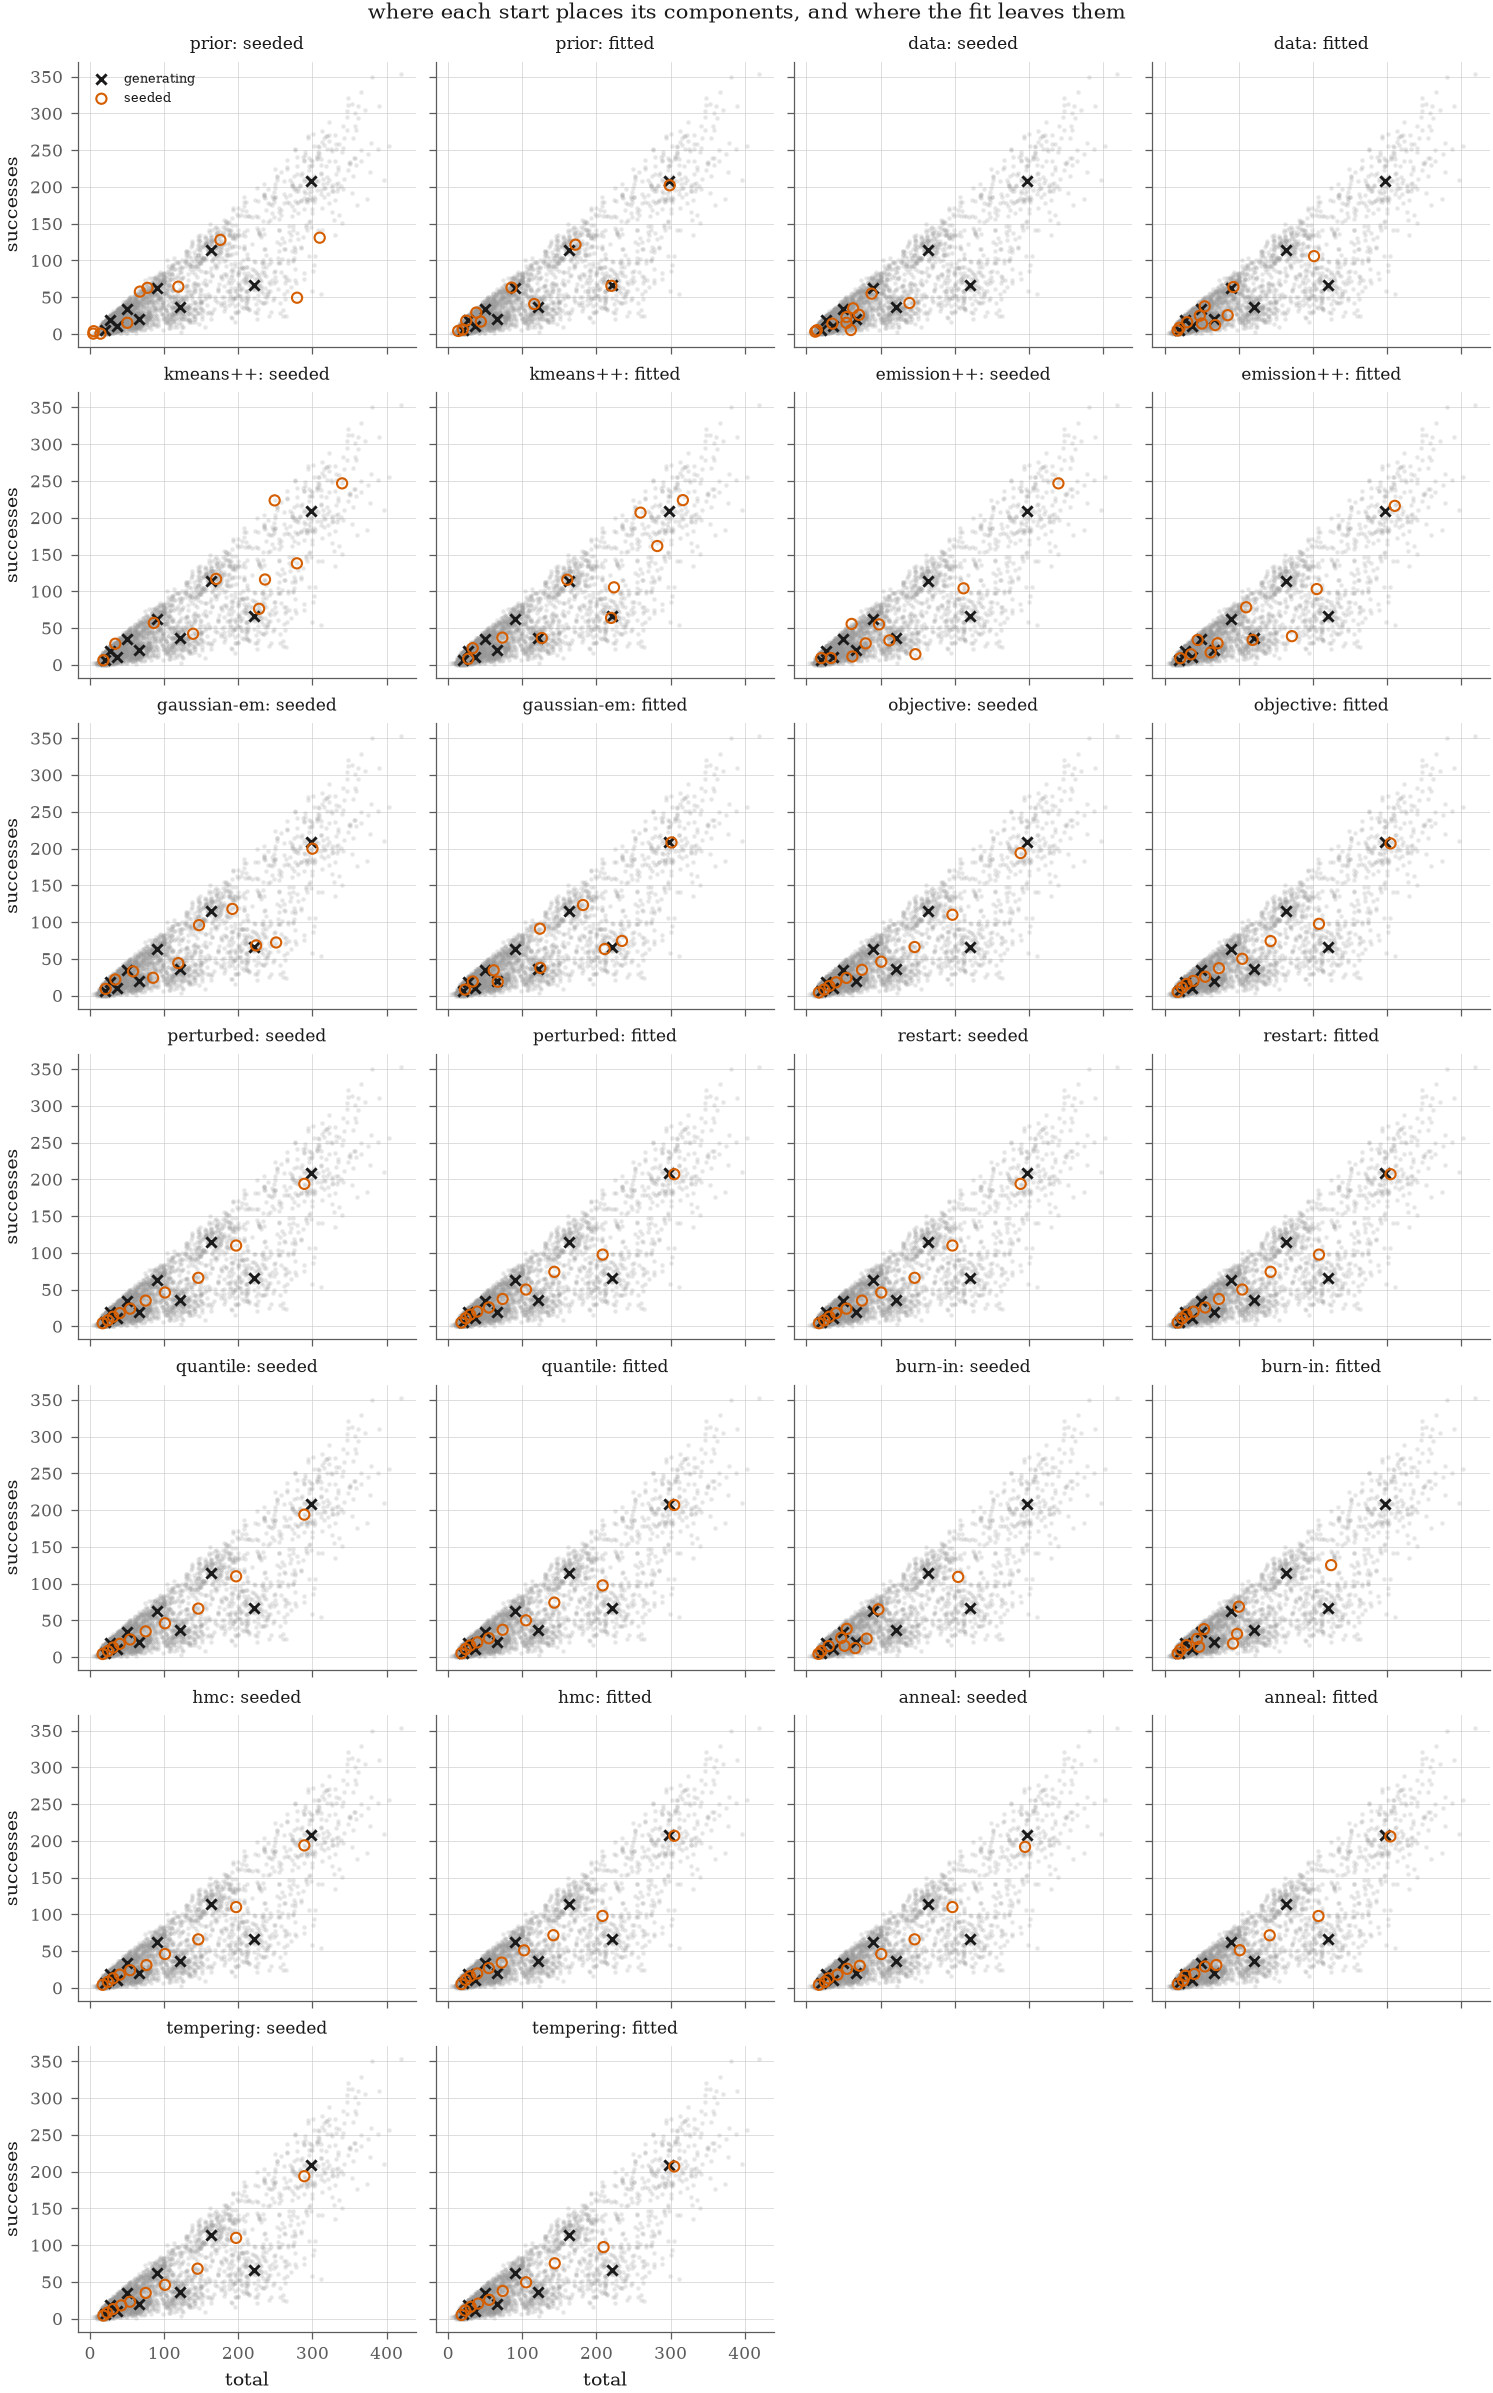

In [7]:
with notebook_style():
    figure, axes = plt.subplots(
        7, 4, figsize=(10.0, 16.0), sharex=True, sharey=True, constrained_layout=True
    )
    panels = axes.ravel()
    for index, name in enumerate(ORDER):
        trial = trials[name][0]
        for side, (family, title) in enumerate(
            (
                (trial.seeded.components, "seeded"),
                (trial.polished.components, "fitted"),
            )
        ):
            axis = panels[2 * index + side]
            axis.scatter(
                instance.observations[:, 0],
                instance.observations[:, 1],
                s=2,
                alpha=0.15,
                color="0.6",
            )
            # Both channels' means: the first two columns of the family's
            # alignment key.
            generating = instance.truth.alignment_key()[:, :2].numpy()
            placed = family.alignment_key()[:, :2].numpy()
            axis.scatter(
                *generating.T, marker="x", s=24, color="0.1", label="generating"
            )
            axis.scatter(
                *placed.T,
                marker="o",
                s=24,
                facecolor="none",
                edgecolor="#D55E00",
                linewidth=1.0,
                label=title,
            )
            axis.set_title(f"{name}: {title}", fontsize=8)
    for axis in panels[2 * len(ORDER) :]:
        axis.set_axis_off()
    for axis in axes[-1]:
        axis.set_xlabel("total")
    for axis in axes[:, 0]:
        axis.set_ylabel("successes")
    panels[0].legend(fontsize=6, loc="upper left")
    figure.suptitle(
        "where each start places its components, and where the fit leaves them",
        fontsize=10,
    )
    plt.show()

## Initialized, then polished

Left: wall seconds from the start's first call against the gap below the
generating parameters, one curve per start at seed 0, every point a `track`
sample. A start that iterates --- the Gaussian EM, the burn-in, the
Hamiltonian chain --- draws its own iterations first, each at the components
it would hand over; the diamond is the handover; the points after it are the
EM iterations. The annealing and tempering runs return their best point and
not the path to it, so their curves start at the handover. Right: each start's
gap at the budget, the bar its mean and the whisker its range over the trials.
The dashed line is the reference at the floor a log axis needs. The x axis is
a wall clock, so the cell is tagged `host-dependent`.

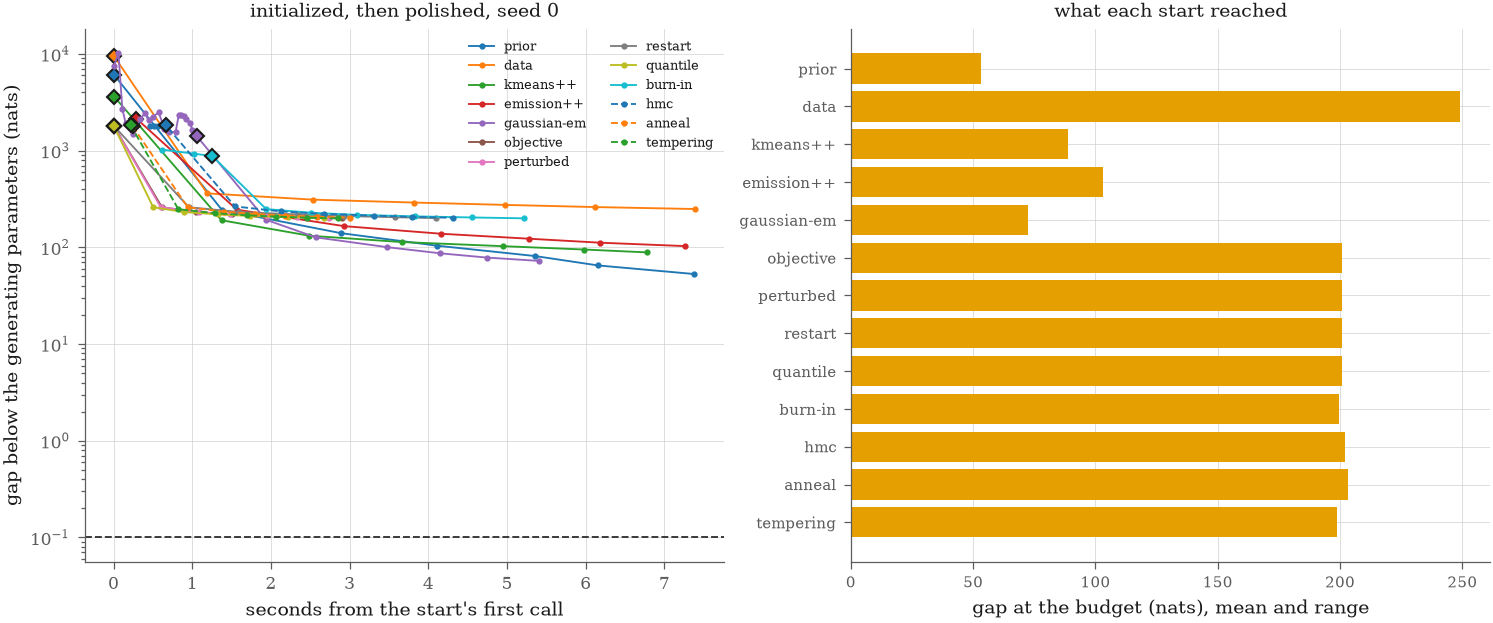

In [8]:
#: Floor on the plotted gap, so a start that passes the reference still has a
#: point on a log axis: a tenth of a nat over 3,000 pairs.
GAP_FLOOR = 0.1

palette = discrete_palette(1)
with notebook_style():
    figure, axes = plt.subplots(1, 2, figsize=(10.0, 4.2), constrained_layout=True)
    for index, name in enumerate(ORDER):
        trial = trials[name][0]
        seconds = np.asarray([point[0] for point in trial.curve])
        gap = np.maximum(
            REFERENCE - np.asarray([point[1] for point in trial.curve]), GAP_FLOOR
        )
        # Solid for the first ten starts and dashed after, since the colour
        # cycle repeats at ten.
        (line,) = axes[0].semilogy(
            seconds,
            gap,
            marker="o",
            markersize=2.0,
            linewidth=0.9,
            linestyle="-" if index < 10 else "--",
            label=name,
        )
        axes[0].plot(
            seconds[trial.handover],
            gap[trial.handover],
            marker="D",
            markersize=5,
            color=line.get_color(),
            markeredgecolor="0.1",
            linestyle="none",
        )
    axes[0].axhline(GAP_FLOOR, color="0.2", linewidth=0.9, linestyle="--")
    axes[0].set_xlabel("seconds from the start's first call")
    axes[0].set_ylabel("gap below the generating parameters (nats)")
    axes[0].set_title("initialized, then polished, seed 0", fontsize=9)
    axes[0].legend(fontsize=6, ncol=2)

    means = np.asarray([np.mean(row.gap) for row in rows])
    whiskers = np.asarray(
        [
            [m - min(row.gap) for m, row in zip(means, rows, strict=True)],
            [max(row.gap) - m for m, row in zip(means, rows, strict=True)],
        ]
    )
    axes[1].barh(ORDER, means, xerr=whiskers, color=palette[0], ecolor="0.2")
    axes[1].axvline(0.0, color="0.2", linewidth=0.9)
    axes[1].invert_yaxis()
    axes[1].set_xlabel("gap at the budget (nats), mean and range")
    axes[1].set_title("what each start reached", fontsize=9)
    axes[1].tick_params(labelsize=7)
    plt.show()

## Read beside experiments 009 and 010

Experiment 009 compared nine of these starts on the key coupled model in
projection, 100 components over 4,000 observations, and had `emission++`
reaching the best projected value on all six of its instances; experiment 010
measured the Gaussian-mixture EM start as a control. What this draw says, from
the compared table:

**Four starts end apart from the rest.** `prior` ends 53.0 nats below the
reference, `gaussian-em` 72.4, `kmeans++` 88.7 and `emission++` 103.0; the four
`opt.initialize` starts, the three chain starts and the burn-in end between
198.7 and 203.0, and `data` at 249.0. At one trial no range is read against
these differences, so none is a ranking, and #559 keeps the defaults.

**Where a start begins does not say where it ends.** `burn-in` hands over the
highest value, -29,148.0, and ends at 199.6; `prior` hands over -34,360.9, the
second lowest, and ends first. Six passes are enough to cross several thousand
nats and not enough to leave the basin a start put the fit in.

**The surrogate starts are one seeding and its neighbours.** `objective`,
`perturbed`, `quantile` and, at seed 0, `restart` seed the same components
(-30,065.0 at the handover); the three chain starts hand over within 41 nats of
it and end within 2.5 nats of it. On 3,000 pairs the Gaussian surrogate is
sharp, and a short chain on it moves little from its nominated point, as
experiment 009 found at the key model.

**The initialization spends under a second of its 120 s.** On this host every
start hands over within 1.0 s and the six EM passes take the remaining 2 to 4 s
(the `host-dependent` table): a budget in seconds is spent by the polish here,
and the passes column is the cost that transfers between hosts.

## Further work

- `TRIALS` is one because a polished fit costs about 3 s on one core, most of
  it the M step's per-component solves; ten trials follow the vectorized M
  step: issue #892.
- The seedings are read on the emission model alone; none is yet read through
  the coupled fit with its lattice and chains: issue #555.
- Spectral seeding by moment inversion, the sixth candidate of #541, is not
  among the starts because no implementation exists: issue #554.
- Nothing here moves a default; the ordering is read beside experiment 009's
  and not tested against it: issue #559.
- The count-pair coupled instance has no notebook of its own, and this one is
  the seventh of the eighteen catalogue rows: issue #682.